# Ariketa 1.2 — Kide-inferentzia (membership inference) — SOLUZIOA

- **Denbora**: 15 min
- **Modalitatea**: taldeka

**Notebook honek soluzio osoa du. Irakasleentzat soilik.**

Ariketa hau **kide-inferentziaren** eraso klasikoaren simulazio sinplifikatua da, Shokri et al. (2017)-en *Membership Inference Attacks Against Machine Learning Models*-en oinarritua, baina askoz arinagoa (ez dugu *shadow models* erabiltzen).

**Ideia nagusia**: gehiegi egokitzen den eredu batek konfiantza handiagoa du entrenamendu-multzoaren adibideetan, eta hau **erasotzaileak baliatu dezake**.

## 1. Setup eta datu-sorrera

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    random_state=RANDOM_STATE,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=RANDOM_STATE
)

print(f"Entrenamendu-multzoa: {X_train.shape[0]} adibide")
print(f"Held-out multzoa:     {X_test.shape[0]} adibide")


[ruta local omitida] UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
[ruta local omitida] UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


Entrenamendu-multzoa: 1000 adibide
Held-out multzoa:     1000 adibide


In [2]:
# Sailkatzaile sakona — gehiegi egokitzeko joera duen Random Forest
eredua = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,      # zuhaitz sakonak
    min_samples_leaf=1,  # adabegi bakoitzean adibide bat baino ez behar
    random_state=RANDOM_STATE,
)
eredua.fit(X_train, y_train)

train_acc = eredua.score(X_train, y_train)
test_acc  = eredua.score(X_test,  y_test)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print(f"Diferentzia (overfit-signal): {train_acc - test_acc:.3f}")


Train accuracy: 1.000
Test accuracy:  0.915
Diferentzia (overfit-signal): 0.085


**Itxaropena**: train ≈ 1.00, test ≈ 0.85-0.92. Diferentzia hori da kide-inferentziaren *signal*-a.

## 2. Erasoa simulatu: train vs test konfiantza

Konfiantza media (train): 0.942
Konfiantza media (test):  0.869


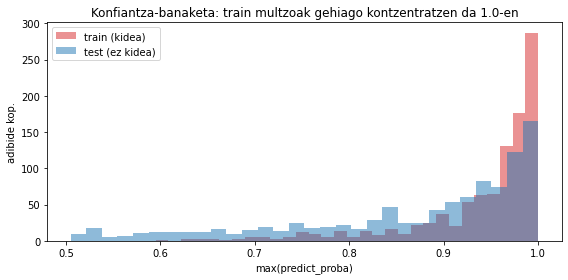

In [3]:
konf_train = eredua.predict_proba(X_train).max(axis=1)
konf_test  = eredua.predict_proba(X_test).max(axis=1)

print(f"Konfiantza media (train): {konf_train.mean():.3f}")
print(f"Konfiantza media (test):  {konf_test.mean():.3f}")

plt.figure(figsize=(8, 4))
plt.hist(konf_train, bins=30, alpha=0.5, label="train (kidea)", color="tab:red")
plt.hist(konf_test,  bins=30, alpha=0.5, label="test (ez kidea)", color="tab:blue")
plt.xlabel("max(predict_proba)")
plt.ylabel("adibide kop.")
plt.legend()
plt.title("Konfiantza-banaketa: train multzoak gehiago kontzentratzen da 1.0-en")
plt.tight_layout()
plt.show()


Eraso-accuracy onena: 0.641 (atalasean 0.94)
Random baseline:      0.500
Abantaila erasotzailearen alde: +0.141


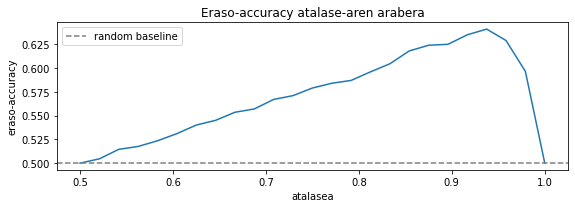

In [4]:
def eraso_accuracy(konf_train, konf_test, atalasea):
    """Eraso-araua: konfiantza > atalasea => 'kide'"""
    asmatuak_train = (konf_train > atalasea).sum()
    asmatuak_test  = (konf_test <= atalasea).sum()
    return (asmatuak_train + asmatuak_test) / (len(konf_train) + len(konf_test))

atalaseak = np.linspace(0.5, 1.0, 25)
accs = [eraso_accuracy(konf_train, konf_test, a) for a in atalaseak]
best_idx = int(np.argmax(accs))
print(f"Eraso-accuracy onena: {accs[best_idx]:.3f} (atalasean {atalaseak[best_idx]:.2f})")
print(f"Random baseline:      0.500")
print(f"Abantaila erasotzailearen alde: {accs[best_idx] - 0.5:+.3f}")

plt.figure(figsize=(8, 3))
plt.plot(atalaseak, accs)
plt.axhline(0.5, color="gray", linestyle="--", label="random baseline")
plt.xlabel("atalasea"); plt.ylabel("eraso-accuracy")
plt.legend(); plt.title("Eraso-accuracy atalase-aren arabera")
plt.tight_layout(); plt.show()


**Itxaropena**: eraso-accuracy ≈ 0.55-0.65, random-aren gainetik. Hau da kide-inferentzia funtzionatzen ari dela frogatzen duen *signal* sendoa.

## 3. Defentsa sinplea: konfiantzaren lausotzea

In [5]:
def lausotu(konfiantza):
    if konfiantza < 0.6:
        return 0.5
    elif konfiantza < 0.85:
        return 0.7
    else:
        return 0.9

konf_train_lausoa = np.array([lausotu(k) for k in konf_train])
konf_test_lausoa  = np.array([lausotu(k) for k in konf_test])

accs_defended = [eraso_accuracy(konf_train_lausoa, konf_test_lausoa, a) for a in atalaseak]
best_def = max(accs_defended)
print(f"Erasoa eredua HUTSEAN:    accuracy onena = {max(accs):.3f}")
print(f"Erasoa DEFENTSAREKIN:     accuracy onena = {best_def:.3f}")
print(f"Defentsaren eragina:      {max(accs) - best_def:+.3f} (jaitsiera)")


Erasoa eredua HUTSEAN:    accuracy onena = 0.641
Erasoa DEFENTSAREKIN:     accuracy onena = 0.616
Defentsaren eragina:      +0.025 (jaitsiera)


**Itxaropena**: defentsarekin eraso-accuracy 0.50 (random baseline-era) hurbiltzen da. Defentsa sinple honek erabilgarritasun-galera handia du (konfiantza zehatza ez itzultzeak aplikazio batzuetan kalte egiten du), baina ideia argi geratzen da: **erasotzaileari ematen zaion informazioa mugatzea = pribatasuna handitzea**.

**Defentsa indartsuagoa: Differential Privacy (DP)**

Beheko adibideak Laplace-zaratazko erantzun-mekanismoa erakusten du.

In [6]:
# DP sinplea: konfiantza-puntuazioei Laplace zarata gehitzea (output perturbation)
# ε txikiagoa => zarata handiagoa => pribatasun handiagoa, baina zehaztasun txikiagoa

def dp_zarata(konfiantzak, epsilon=1.0, sentsibilitatea=1.0):
    """Output perturbation: Laplace zarata.

    epsilon: pribatasun-aurrekontua (txikia = pribatasun handia)
    sentsibilitatea: konfiantzaren errango maximoa (probabilitate batentzat = 1.0)
    """
    eskala = sentsibilitatea / epsilon
    zarata = np.random.laplace(loc=0.0, scale=eskala, size=konfiantzak.shape)
    return np.clip(konfiantzak + zarata, 0.0, 1.0)

for eps in [0.1, 0.5, 1.0, 5.0]:
    np.random.seed(RANDOM_STATE)
    konf_train_dp = dp_zarata(konf_train, epsilon=eps)
    konf_test_dp  = dp_zarata(konf_test,  epsilon=eps)
    accs_dp = [eraso_accuracy(konf_train_dp, konf_test_dp, a) for a in atalaseak]
    print(f"epsilon={eps:>4.1f}: eraso-accuracy onena = {max(accs_dp):.3f}")


epsilon= 0.1: eraso-accuracy onena = 0.500
epsilon= 0.5: eraso-accuracy onena = 0.500
epsilon= 1.0: eraso-accuracy onena = 0.509
epsilon= 5.0: eraso-accuracy onena = 0.557


**Interpretazioa**: ε txikia (adib. 0.1) → zarata handia → eraso-accuracy ≈ 0.50 (random). ε handiena (5.0) → zarata txikia → eraso-accuracy berriz altua. **Trade-off**: pribatasuna vs zehaztasun-galera ε-rekin kontrolatzen da (DP definizio formalaren araberako pribatasun-aurrekontua).

---
## 4. Eztabaida — SOLUZIOAK

**A) Zer informazio lor dezake erasotzaileak?**

- Konkretuki, ea langile zehatz bat ereduaren entrenamendu-multzoan **zegoen**, hau da, enpresan lan egin zuen (informazio pertsonal sentibera, agian uneko enpresan lehenagoko esperientzia ezkutatua).
- Entrenamendu-datuen *output*-aren konfiantza-maila baliatuta, **etekin-aurreikuspena bera** (langile X "errendimendu baxua" multzoan dago) inferi daiteke. Hori datu pertsonala da, eta gainera zentsibilki *profiling*-zko erabakiari lotua.
- Errepikatutako kontsultekin, sailkapenaren mugak (*decision boundary*) marraztu eta langile osoaren profila berreraiki daiteke (jaiotze-data, lekua, antzinatasuna).

**B) Urratutako legeak (≥3 zehatz):**

- **GDPR 5. art. (helburu-mugatzea, datu-minimizazioa)**: etekin-aurreikuspenerako bildutako datuak ez dira hirugarrenek berreskuratzeko erabili behar.
- **GDPR 9. art.**: ondoriozta daitezkeen kategoria sentikorrak (osasuna, sindikatuko kidetza inplizituki) babes berezia dute.
- **GDPR 22. art.**: erabaki automatizatu indibidualizatua, pertsonen gainean "ondorio nabarmenak" izan ditzakeena.
- **GDPR 25. art. (Privacy by Design)** eta **32. art. (segurtasun-neurriak)** ez aplikatzeak haustea suposatzen du.
- **AI Act III. eranskina, 4. atala**: enplegua eta langileen kudeaketa **arrisku altuko erabilera** da → 9., 12., 14. eta 15. art. derrigorrezkoak.

**C) Hiru babes-neurri zehatz:**

1. **Pribatasun Diferentziala** entrenamenduan (DP-SGD), ε zuhur batekin (adib. ε ≤ 1) — kide-inferentziaren probabilitatea matematikoki mugatzen du. Aurreko kode-zelulan ikusi dugu nola ε-ek erasoa efektiboki desaktibatzen duen.
2. **Output-aren lausotzea**: konfiantza zehatza ez itzuli; tarteak (`baxua/ertaina/altua`) edo Top-1 etiketa soilik.
3. **Rate limiting eta auditoria** sistema-mailan: erabiltzaile berak galdera asko egiten baditu, alarma piztu.

Beste neurri osagarriak:

- **Datu-minimizazioa eta seudonimizazioa** entrenamendu-fasean.
- **Giza gainbegiraketa** (AI Act 14. art.) eta **fallback** plana: aurreikuspena ez da inoiz erabaki bakarra HR-erabakietan.
- **EIPD (GDPR 35. art.)** sistema zabaldu aurretik, eta langileen ordezkariekin (lan-batzordea) kontsulta.

**D) Hausnarketa: zergatik arrisku altua?**

AI Act III. eranskinaren 4. atalaren arabera, **enpleguaren eta langileen kudeaketaren** AA sistemak (kontratazioa, ebaluazioa, erabakitzea sustapen edo kanporatze-prozesuetan) arrisku altukoak dira ondorengoengatik:

- **Boterearen asimetria**: langileak ez du erraz kontrastatu edo kontestatzeko aukerarik enpresaren erabaki bati.
- **Eskubide funtsezkoetan eragina**: lanaren eskubidea, ez-diskriminazioa.
- **Diskriminazioaren errepikatzea**: datu historikoak alborapenak izan ditzakete (genero, jatorri, adin).

Ondorioz, GDPR 22. art.-aren araberako **"erabaki automatizatu indibidualizatu"** ohiko adibidea da.

---
## 5. Ebaluatzailearen gida (irakaslea)

| Atala | Galdera-gakoa | Adierazlea |
|-------|---------------|------------|
| Setup | Sailkatzailea entrenatu da? | Train acc > test acc (gehiegi-egokitzapen-signala). |
| Erasoa | Accuracy >0.5? | Histograma + atalase-azterketa egin dute. |
| Defentsa | Lausotzeak / DP-ak erasoa jaisten du? | Aurretik-ondoren konparaketa zenbakizkoa. |
| Eztabaida | Lege-erreferentzia zehatzak? | GDPR 9, 22, 25 + AI Act III.4 aipatzen ditu. |